# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.func import functional_call

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')

Using device : cpu


# Data

In [3]:
batch_size = 64

train_ratio = 2/3
meta_ratio = 1/6

In [4]:
mnist_train = torchvision.datasets.MNIST(
    root="data/data_MNIST",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)

mnist_test = torchvision.datasets.MNIST("data/data_MNIST",
        train=False,
        download=True,
        transform=torchvision.transforms.ToTensor(),
)


train_size = int(train_ratio * len(mnist_train))
meta_size = int(meta_ratio * len(mnist_train))
val_size = len(mnist_train) - train_size - meta_size

dataset_train, dataset_meta, dataset_val = torch.utils.data.random_split(mnist_train, [train_size, meta_size, val_size])

dataset_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataset_meta = torch.utils.data.DataLoader(dataset_meta, batch_size=batch_size, shuffle=True)
dataset_val = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
dataset_test = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

# Useful functions

In [5]:
def plot_images_from_dataloader(dataloader, num_images=5, class_names=None):
    images, labels = next(iter(dataloader))
    images = images[:num_images]
    labels = labels[:num_images]
    
    images_np = images.numpy()
    images_np = np.transpose(images_np, (0, 2, 3, 1)) 

    plt.figure(figsize=(15, 3))
    
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images_np[i], cmap='gray')
        if class_names:
            title = f"Class: {class_names[labels[i]]}"
        else:
            title = f"Label: {labels[i]}"
        
        plt.title(title)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [6]:
def accuracy(prediction, gt):
    pred = torch.argmax(prediction, dim=1)
    correct = (pred == gt ).sum()
    acc = correct.item() / gt.size(0)
    return acc

In [7]:
def evaluate(model, dataloader):
    model.eval()
    eval_preds = []
    eval_labels = []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = model(imgs)
            eval_preds.append(pred)
            eval_labels.append(labels)
    pred = torch.cat(eval_preds)
    label = torch.cat(eval_labels)

    acc = accuracy(pred, label)
    return acc

In [8]:
def train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, scheduler=None, verbose=True):
    for epoch in range(num_epochs):
        model.train()
        for imgs, labels in dataset_train:
            imgs, labels = imgs.to(device), labels.to(device)
            prediction = model(imgs)
            loss = criterion(prediction, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        
        val_acc = evaluate(model, dataset_val)
        if verbose:
            if scheduler is None:
                print(f' -> Epoch {epoch+1} | Val accuracy : {(100*val_acc):.2f}%')
            else:
                print(f"  -> Epoch {epoch+1} | lr = {optimizer.param_groups[0]['lr']} | Val accuracy : {(100*val_acc):.2f}‰")

In [9]:
def train_meta(model, criterion, dataset_train, dataset_meta, dataset_val, num_epochs, log_lr, meta_optimizer):

    model_params = dict(model.named_parameters())

    for epoch in range(num_epochs):
        model.train()
        for (train_imgs, train_labels), (meta_imgs, meta_labels) in zip(dataset_train, dataset_meta):
            train_imgs = train_imgs.to(device)
            train_labels = train_labels.to(device)

            meta_imgs = meta_imgs.to(device)
            meta_labels = meta_labels.to(device)

            lr = torch.exp(log_lr)

            train_pred = functional_call(model, model_params, (train_imgs,))
            train_loss = criterion(train_pred, train_labels)

            grads = torch.autograd.grad(train_loss, model_params.values(), create_graph=True)
            
            updated_params = {}
            for (name, param), grad in zip(model_params.items(), grads):
                updated_params[name] = param - lr * grad

            meta_pred = functional_call(model, updated_params, (meta_imgs, ))
            meta_loss = criterion(meta_pred, meta_labels)

            meta_optimizer.zero_grad()
            meta_loss.backward()
            meta_optimizer.step()

            with torch.no_grad():
                for name in model_params.keys():
                    model_params[name].copy_(updated_params[name].data)

        val_acc = evaluate(model, dataset_val)

        print(f"Epoch {epoch+1} | lr={lr} | meta_loss={meta_loss.item():.4f} | val_acc={100*val_acc:.2f}%" )

# Model

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
        self.drop = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.conv1(x)           # (B, 10, 24, 24)
        x = F.max_pool2d(x, 2)      # (B, 10, 12, 12)
        x = F.relu(x)
        x = self.conv2(x)           # (B, 20, 8, 8)
        x = F.max_pool2d(x, 2)      # (B, 20, 4, 4)
        x = F.relu(x)
        x = x.view(-1, 320)         # (B, 320)
        x = self.fc1(x)             # (B, 50)
        x = F.relu(x)
        x = self.drop(x)
        x = self.fc2(x)             # (B, 10)
        return x

# Constant LR

## Lr-tuning

Starting lr-tuning
  -> lr = 1e-04 | accuracy = 9.81%
  -> lr = 5e-04 | accuracy = 21.37%
  -> lr = 1e-03 | accuracy = 21.68%
  -> lr = 5e-03 | accuracy = 90.31%
  -> lr = 1e-02 | accuracy = 94.15%


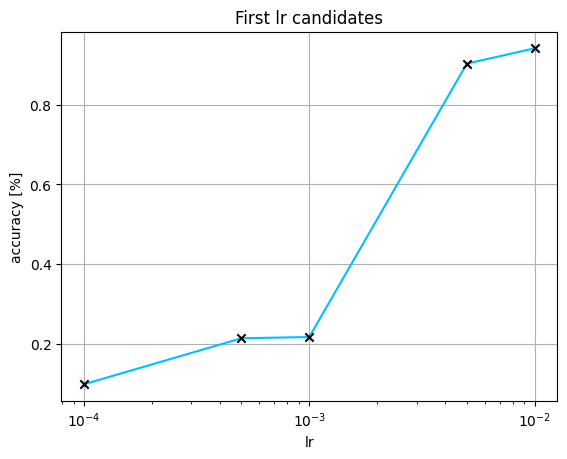

In [11]:
lr_candidates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
val_acc = []
num_epochs = 5
criterion = nn.CrossEntropyLoss()

print('Starting lr-tuning')
for lr in lr_candidates:
    model = CNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, verbose=False)
    acc = evaluate(model, dataset_val)
    val_acc.append(acc)
    print(f"  -> lr = { lr:.0e} | accuracy = {(100*acc):.2f}%")

plt.semilogx(lr_candidates, val_acc, color='deepskyblue')
plt.scatter(lr_candidates, val_acc, marker='x', color='black', zorder=3)
plt.grid()
plt.xlabel('lr')
plt.ylabel('accuracy [%]')
plt.title('First lr candidates')
plt.show()

Starting lr-tuning
  -> lr = 5e-03 | accuracy = 94.36%
  -> lr = 1e-02 | accuracy = 96.21%
  -> lr = 5e-02 | accuracy = 98.32%
  -> lr = 1e-01 | accuracy = 98.53%


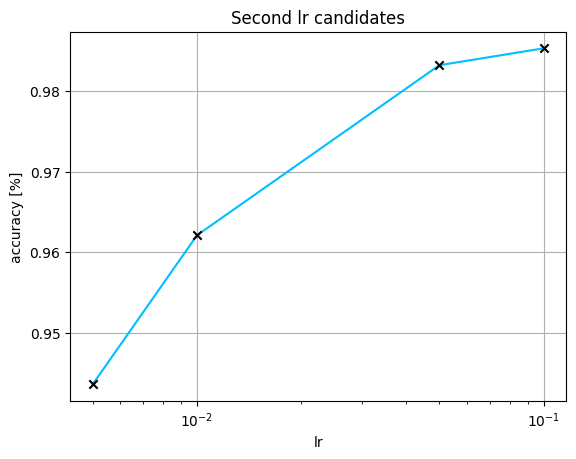

In [12]:
lr_candidates = [5e-3, 1e-2, 5e-2, 1e-1]
val_acc = []
num_epochs = 10
criterion = nn.CrossEntropyLoss()

print('Starting lr-tuning')
for lr in lr_candidates:
    model = CNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, verbose=False)
    acc = evaluate(model, dataset_val)
    val_acc.append(acc)
    print(f"  -> lr = { lr:.0e} | accuracy = {(100*acc):.2f}%")

plt.semilogx(lr_candidates, val_acc, color='deepskyblue')
plt.scatter(lr_candidates, val_acc, marker='x', color='black', zorder=3)
plt.grid()
plt.xlabel('lr')
plt.ylabel('accuracy [%]')
plt.title('Second lr candidates')
plt.show()

Starting lr-tuning
  -> lr = 1e-01 | accuracy = 98.75%
  -> lr = 2e-01 | accuracy = 98.81%
  -> lr = 5e-01 | accuracy = 98.56%


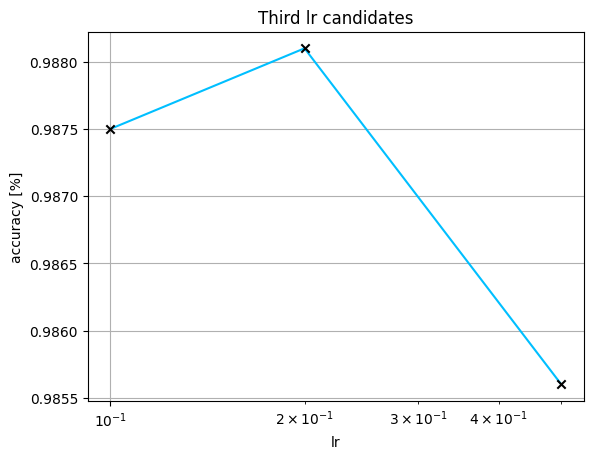

In [13]:
lr_candidates = [0.1, 0.2, 0.5]
val_acc = []
num_epochs = 15
criterion = nn.CrossEntropyLoss()

print('Starting lr-tuning')
for lr in lr_candidates:
    model = CNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, verbose=False)
    acc = evaluate(model, dataset_val)
    val_acc.append(acc)
    print(f"  -> lr = { lr:.0e} | accuracy = {(100*acc):.2f}%")

plt.semilogx(lr_candidates, val_acc, color='deepskyblue')
plt.scatter(lr_candidates, val_acc, marker='x', color='black', zorder=3)
plt.grid()
plt.xlabel('lr')
plt.ylabel('accuracy [%]')
plt.title('Third lr candidates')
plt.show()

In [14]:
best_lr = lr_candidates[np.argmax(val_acc)]
print(f'Best learning rate : {best_lr}')

Best learning rate : 0.2


## Training loop

In [15]:
num_epochs = 50

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=best_lr)

print('Start training')
train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs)

test_pred = []
test_label = []
model.eval()
with torch.no_grad():
    for imgs, label in dataset_test:
        imgs, label = imgs.to(device), label.to(device)
        pred = model(imgs)
        test_pred.append(pred)
        test_label.append(label)

pred = torch.cat(test_pred)
label = torch.cat(test_label)

test_acc = accuracy(pred, label)

print(f'Testing accuracy : {(100*test_acc):.2f}')

Start training
 -> Epoch 1 | Val accuracy : 96.71%
 -> Epoch 2 | Val accuracy : 97.61%
 -> Epoch 3 | Val accuracy : 98.27%
 -> Epoch 4 | Val accuracy : 98.41%
 -> Epoch 5 | Val accuracy : 98.39%
 -> Epoch 6 | Val accuracy : 98.41%
 -> Epoch 7 | Val accuracy : 98.66%
 -> Epoch 8 | Val accuracy : 98.62%
 -> Epoch 9 | Val accuracy : 98.77%
 -> Epoch 10 | Val accuracy : 98.63%
 -> Epoch 11 | Val accuracy : 98.67%
 -> Epoch 12 | Val accuracy : 98.62%
 -> Epoch 13 | Val accuracy : 98.65%
 -> Epoch 14 | Val accuracy : 98.50%
 -> Epoch 15 | Val accuracy : 98.89%
 -> Epoch 16 | Val accuracy : 98.75%
 -> Epoch 17 | Val accuracy : 98.68%
 -> Epoch 18 | Val accuracy : 98.91%
 -> Epoch 19 | Val accuracy : 98.80%
 -> Epoch 20 | Val accuracy : 98.77%
 -> Epoch 21 | Val accuracy : 98.35%
 -> Epoch 22 | Val accuracy : 98.66%
 -> Epoch 23 | Val accuracy : 98.74%
 -> Epoch 24 | Val accuracy : 98.72%
 -> Epoch 25 | Val accuracy : 98.96%
 -> Epoch 26 | Val accuracy : 98.77%
 -> Epoch 27 | Val accuracy : 98

# Scheduler

## StepLR

### lr-tuning

Starting lr-tuning
  -> lr = 1e-01 | accuracy = 98.69%
  -> lr = 2e-01 | accuracy = 98.74%
  -> lr = 5e-01 | accuracy = 98.50%


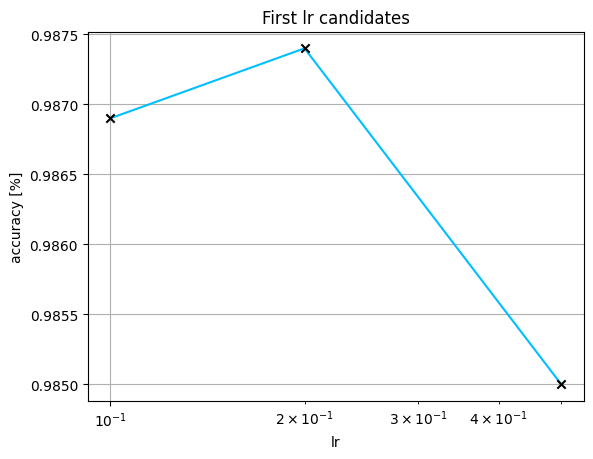

In [16]:
lr_candidates = [0.1, 0.2, 0.5]
val_acc = []
num_epochs = 10
criterion = nn.CrossEntropyLoss()

print('Starting lr-tuning')
for lr in lr_candidates:
    model = CNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, scheduler, verbose=False)
    acc = evaluate(model, dataset_val)
    val_acc.append(acc)
    print(f"  -> lr = { lr:.0e} | accuracy = {(100*acc):.2f}%")

plt.semilogx(lr_candidates, val_acc, color='deepskyblue')
plt.scatter(lr_candidates, val_acc, marker='x', color='black', zorder=3)
plt.grid()
plt.xlabel('lr')
plt.ylabel('accuracy [%]')
plt.title('First lr candidates')
plt.show()

In [17]:
best_lr = lr_candidates[np.argmax(val_acc)]
print(f'Best learning rate : {best_lr}')

Best learning rate : 0.2


### Training

In [18]:
num_epochs = 50

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print('Start training')
train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, scheduler)

test_pred = []
test_label = []
model.eval()
with torch.no_grad():
    for imgs, label in dataset_test:
        imgs, label = imgs.to(device), label.to(device)
        pred = model(imgs)
        test_pred.append(pred)
        test_label.append(label)

pred = torch.cat(test_pred)
label = torch.cat(test_label)

test_acc = accuracy(pred, label)

print(f'Testing accuracy : {(100*test_acc):.2f}')

Start training
  -> Epoch 1 | lr = 0.2 | Val accuracy : 96.38‰
  -> Epoch 2 | lr = 0.2 | Val accuracy : 97.57‰
  -> Epoch 3 | lr = 0.2 | Val accuracy : 98.12‰
  -> Epoch 4 | lr = 0.2 | Val accuracy : 98.24‰
  -> Epoch 5 | lr = 0.1 | Val accuracy : 98.44‰
  -> Epoch 6 | lr = 0.1 | Val accuracy : 98.69‰
  -> Epoch 7 | lr = 0.1 | Val accuracy : 98.66‰
  -> Epoch 8 | lr = 0.1 | Val accuracy : 98.73‰
  -> Epoch 9 | lr = 0.1 | Val accuracy : 98.76‰
  -> Epoch 10 | lr = 0.05 | Val accuracy : 98.77‰
  -> Epoch 11 | lr = 0.05 | Val accuracy : 98.89‰
  -> Epoch 12 | lr = 0.05 | Val accuracy : 98.87‰
  -> Epoch 13 | lr = 0.05 | Val accuracy : 98.95‰
  -> Epoch 14 | lr = 0.05 | Val accuracy : 98.97‰
  -> Epoch 15 | lr = 0.025 | Val accuracy : 98.80‰
  -> Epoch 16 | lr = 0.025 | Val accuracy : 98.91‰
  -> Epoch 17 | lr = 0.025 | Val accuracy : 98.94‰
  -> Epoch 18 | lr = 0.025 | Val accuracy : 98.92‰
  -> Epoch 19 | lr = 0.025 | Val accuracy : 98.87‰
  -> Epoch 20 | lr = 0.0125 | Val accuracy : 98.

## Cosine

### lr-tuning

Starting lr-tuning
  -> lr = 1e-01 | accuracy = 98.43%
  -> lr = 2e-01 | accuracy = 98.87%
  -> lr = 5e-01 | accuracy = 98.81%


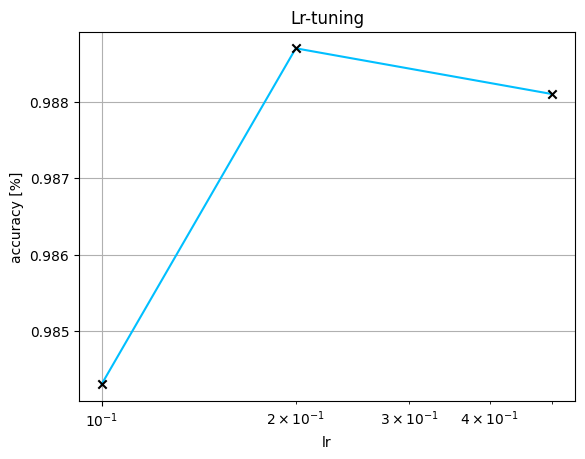

In [19]:
lr_candidates = [0.1, 0.2, 0.5]
val_acc = []
num_epochs = 10
criterion = nn.CrossEntropyLoss()

print('Starting lr-tuning')
for lr in lr_candidates:
    model = CNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, scheduler, verbose=False)
    acc = evaluate(model, dataset_val)
    val_acc.append(acc)
    print(f"  -> lr = { lr:.0e} | accuracy = {(100*acc):.2f}%")

plt.semilogx(lr_candidates, val_acc, color='deepskyblue')
plt.scatter(lr_candidates, val_acc, marker='x', color='black', zorder=3)
plt.grid()
plt.xlabel('lr')
plt.ylabel('accuracy [%]')
plt.title('Lr-tuning')
plt.show()

In [20]:
best_lr = lr_candidates[np.argmax(val_acc)]
print(f'Best learning rate : {best_lr}')

Best learning rate : 0.2


### Training

In [21]:
num_epochs = 50

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print('Start training')
train(model, criterion, dataset_train, dataset_val, optimizer, num_epochs, scheduler)

test_pred = []
test_label = []
model.eval()
with torch.no_grad():
    for imgs, label in dataset_test:
        imgs, label = imgs.to(device), label.to(device)
        pred = model(imgs)
        test_pred.append(pred)
        test_label.append(label)

pred = torch.cat(test_pred)
label = torch.cat(test_label)

test_acc = accuracy(pred, label)

print(f'Testing accuracy : {(100*test_acc):.2f}')

Start training
  -> Epoch 1 | lr = 0.19980267284282716 | Val accuracy : 96.70‰
  -> Epoch 2 | lr = 0.1992114701314478 | Val accuracy : 97.67‰
  -> Epoch 3 | lr = 0.19822872507286887 | Val accuracy : 98.04‰
  -> Epoch 4 | lr = 0.19685831611286309 | Val accuracy : 98.41‰
  -> Epoch 5 | lr = 0.19510565162951535 | Val accuracy : 98.68‰
  -> Epoch 6 | lr = 0.19297764858882513 | Val accuracy : 98.53‰
  -> Epoch 7 | lr = 0.19048270524660196 | Val accuracy : 98.64‰
  -> Epoch 8 | lr = 0.18763066800438635 | Val accuracy : 98.43‰
  -> Epoch 9 | lr = 0.1844327925502015 | Val accuracy : 98.70‰
  -> Epoch 10 | lr = 0.18090169943749473 | Val accuracy : 98.83‰
  -> Epoch 11 | lr = 0.17705132427757891 | Val accuracy : 98.77‰
  -> Epoch 12 | lr = 0.17289686274214114 | Val accuracy : 98.81‰
  -> Epoch 13 | lr = 0.16845471059286884 | Val accuracy : 98.86‰
  -> Epoch 14 | lr = 0.16374239897486895 | Val accuracy : 98.96‰
  -> Epoch 15 | lr = 0.15877852522924732 | Val accuracy : 98.92‰
  -> Epoch 16 | lr = 

# Meta learning

In [22]:
num_epochs = 50

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()

log_lr = nn.Parameter(torch.tensor(-2.303, device=device))
meta_optimizer = torch.optim.Adam([log_lr], lr=0.005)

print('Start training')
train_meta(model, criterion, dataset_train, dataset_meta, dataset_val,
        num_epochs, log_lr, meta_optimizer)

test_pred = []
test_label = []
model.eval()
with torch.no_grad():
    for imgs, label in dataset_test:
        imgs, label = imgs.to(device), label.to(device)
        pred = model(imgs)
        test_pred.append(pred)
        test_label.append(label)

pred = torch.cat(test_pred)
label = torch.cat(test_label)

test_acc = accuracy(pred, label)

print(f'Testing accuracy : {(100*test_acc):.2f}')

Start training
Epoch 1 | lr=0.06583234667778015 | meta_loss=0.6101 | val_acc=85.53%
Epoch 2 | lr=0.04754289984703064 | meta_loss=0.4394 | val_acc=91.89%
Epoch 3 | lr=0.039874814450740814 | meta_loss=0.8354 | val_acc=92.93%
Epoch 4 | lr=0.03469701483845711 | meta_loss=0.1570 | val_acc=94.60%
Epoch 5 | lr=0.03119303286075592 | meta_loss=0.4298 | val_acc=95.37%
Epoch 6 | lr=0.027403388172388077 | meta_loss=0.6834 | val_acc=95.58%
Epoch 7 | lr=0.024780940264463425 | meta_loss=0.2995 | val_acc=95.86%
Epoch 8 | lr=0.023624882102012634 | meta_loss=0.3703 | val_acc=96.02%
Epoch 9 | lr=0.021654624491930008 | meta_loss=0.1600 | val_acc=96.36%
Epoch 10 | lr=0.020152175799012184 | meta_loss=0.3418 | val_acc=96.44%
Epoch 11 | lr=0.01885809376835823 | meta_loss=0.1488 | val_acc=96.45%
Epoch 12 | lr=0.01744871772825718 | meta_loss=0.3216 | val_acc=96.61%
Epoch 13 | lr=0.01663358137011528 | meta_loss=0.3670 | val_acc=96.69%
Epoch 14 | lr=0.015388941392302513 | meta_loss=0.1402 | val_acc=96.82%
Epoch 1